# Epicyclic timescales -- TRM model: `TRM_paper`

Companion, additive analysis alongside the harmonic-fit pipeline (see
`harmonic_pipeline_TRM_paper.ipynb` / `CLAUDE.md`) -- not one of its
Section 0 deliverables. All computation lives in `timescales.py`; this
notebook only imports it and displays figures, mirroring the split already
used by `harmonic_fit.py` / `harmonic_plots.py`.

Other TRM models with a results/ring_results.ecsv already fit: fixed_PA42.

**Three problems, fixed in priority order** (the fit cannot be assessed
until it runs on correct inputs):

1. **Inputs.** The original scratch notebook hardcoded a rotation curve and
   a `V_rad(R)` array as literals rather than reading them from disk. The
   numbers themselves were not wrong -- they were a valid snapshot of a
   `TRM_paper` TRM run -- but pinning them as literals meant they went
   silently stale the moment `TRM_paper`'s TRM outputs were re-run
   (which is exactly what happened between the original notebook and this
   refactor). Every number below now comes from `TRM_paper`'s own
   ringlog and its own `results/ring_results.ecsv` instead -- no numeric
   literal for radius, velocity, PA, inclination, or scale anywhere outside
   `timescales.Config` -- so a re-run of the TRM fit can never leave this
   notebook out of sync again.
2. **Void geometry.** The void's sky corners are deprojected with
   `harmonic_fit.deproject_pixel_offsets` -- the exact rotation/handedness
   convention `make_geometry` uses internally -- instead of a second,
   independently-defined (and differently-handed) deprojection. The
   resulting radius is checked against the rotation curve's radial coverage
   before evaluating the fit there.
3. **The epicyclic ("kick") fit.** The original three-parameter
   `scipy.optimize.curve_fit` pegged its amplitude at the lower search bound
   -- meaning the quoted `t = 94.5 +/- 338.2 Myr` was never a measurement,
   just an artifact of an unconstrained optimizer. It is replaced by a 2D
   grid search over `(V0, t)` with `alpha` fixed at its citable value
   (Wallin & Struck-Marcell 1994, Sec 3.1) instead of fitted (four data
   points cannot constrain three free parameters). The salvageable physical
   result is an **upper limit on the kick amplitude V0**, not a point
   estimate of `t`.

**Rotation-curve fit.** With only a handful of rings, an *interpolating*
natural cubic spline is forced exactly through ring-to-ring scatter that is
well within each ring's own `E_VROT` uncertainty, which shows up as a visible
hump-and-dip that isn't a real kinematic feature -- worst in the extrapolated
region the void radius sits in. `timescales.generate_kinematic_curve` fits a
weighted low-order polynomial instead (`cfg.rotation_curve_poly_order`,
default 1/linear; weights `1/sigma^2` with `sigma = (E_VROT1+E_VROT2)/2`),
which stays close to flat where the data support it rather than chasing
noise.

**Sign convention.** `harmonic_fit.py`'s `s1` keeps the raw fit sign, and
`CLAUDE.md` 2.6.1 resolves -- for this galaxy, given the near side at
`theta = +90 deg` -- true outward `V_rad = -s1`. The epicyclic "kick" model
here is written with `V_R > 0` meaning outward (Wallin & Struck-Marcell
1994), so `timescales.load_radial_velocities` flips the sign explicitly on
read: `v_R_outward = -s1`. See `timescales.py`'s docstring for the citation.

## Config

The one cell in this notebook you are expected to edit -- normally just
`TRM_DIR`. `timescales.Config`'s other fields are the epicyclic model's
science constants (`alpha`, grid ranges, the epoch window used to quote the
`V0` upper limit) and the void's external RA/Dec corner coordinates -- see
`timescales.py` for what each one means and where it comes from. The bridge
timescale (Section 4 of the spec) is left unset here: no measured bridge
extent/velocity or sky position angle exists anywhere in this repo, so it is
skipped (printed clearly, not guessed) until those numbers are supplied.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import harmonic_fit as hf
import harmonic_plots as hp  # only for hp.custom_rcparams's mpl.rcParams.update side effect
import timescales as ts

repo_root = Path.cwd()
TRM_DIR = "TRM_paper"  # which (already-fit) TRM model directory to run; see build_timescales_notebook.eligible_models

trm_dir = repo_root / TRM_DIR
cfg = ts.Config(
    trm_dir=trm_dir,
    ringlog_path=hf.find_ringlog(trm_dir),
    results_dir=trm_dir / "results",
)
cfg

Config(trm_dir=PosixPath('/Users/24398082/projects/SM_harmonic_fit/TRM_paper'), ringlog_path=PosixPath('/Users/24398082/projects/SM_harmonic_fit/TRM_paper/stage_1_opt_parameters.txt'), results_dir=PosixPath('/Users/24398082/projects/SM_harmonic_fit/TRM_paper/results'), output_dir=PosixPath('/Users/24398082/projects/SM_harmonic_fit/TRM_paper/results'), side='both', rotation_curve_poly_order=1, alpha=0.5, r_ref_kpc=15.0, v0_grid_max_kms=200.0, v0_grid_step_kms=1.0, t_grid_max_myr=400.0, t_grid_step_myr=1.0, t_estimate_lo_myr=84.0, t_estimate_hi_myr=100.0, upper_limit_cl=0.68, void_center_hms=((17, 29, 9.588425), (-62, 26, 44.5182)), void_top_hms=((17, 29, 12.171038), (-62, 26, 27.349434)), void_bottom_hms=((17, 29, 11.630122), (-62, 27, 20.094748)), legacy_void_r_avg_kpc=13.88, legacy_void_dtheta_deg=105.75, bridge_dR_over_dV_kpc_per_kms=None, bridge_pa_deg=None, bridge_theta_sensitivity_step_deg=5.0)

## 1. Inputs -- single source of truth

Rotation curve, its errors, PA, inclination, and `kpc_per_arcsec` all come
from `cfg.ringlog_path`. The radial-velocity array comes from
`results/ring_results.ecsv` (side="both", the primary weighting recorded in
its metadata), sign-flipped on read (see above).

In [2]:
rc = ts.load_rotation_curve(cfg.ringlog_path)
rv = ts.load_radial_velocities(cfg.results_dir, side=cfg.side)

print(f"ringlog = {cfg.ringlog_path.name}")
print(f"kpc_per_arcsec = {rc.kpc_per_arcsec:.5f}  INC = {rc.inc_deg:.3f} deg  P.A. = {rc.pa_deg:.3f} deg")
print(f"XPOS,YPOS = {rc.xpos_pix:.3f}, {rc.ypos_pix:.3f} pix\n")

print(f"{'R [kpc]':>10}{'VROT [km/s]':>14}{'-E_VROT1':>12}{'+E_VROT2':>12}")
for R, V, elo, ehi in zip(rc.radii_kpc, rc.v_kms, rc.v_err_lo, rc.v_err_hi):
    print(f"{R:10.3f}{V:14.3f}{elo:12.3f}{ehi:12.3f}")

print(f"\n{'ring':>6}{'R [kpc]':>10}{'s1 [km/s]':>12}{'v_R outward [km/s]':>20}{'sigma [km/s]':>14}")
for i, R, s1, vR, sig in zip(rv.ring_index, rv.radii_kpc, rv.s1_raw_kms, rv.v_R_outward_kms, rv.sigma_kms):
    print(f"{i:6d}{R:10.3f}{s1:12.3f}{vR:20.3f}{sig:14.3f}")

ringlog = stage_1_opt_parameters.txt
kpc_per_arcsec = 0.33889  INC = 49.345 deg  P.A. = 53.445 deg
XPOS,YPOS = 24.539, 26.310 pix

   R [kpc]   VROT [km/s]    -E_VROT1    +E_VROT2
    14.572       256.396      52.097      32.634
    17.860       295.722      17.518      11.846
    21.147       300.175      10.140       8.698
    24.434       300.991      11.329       8.922

  ring   R [kpc]   s1 [km/s]  v_R outward [km/s]  sigma [km/s]
     0    14.572      -6.659               6.659        11.097
     1    17.860     -47.709              47.709         6.360
     2    21.147     -47.870              47.870         7.355
     3    24.434     -40.799              40.799         8.290


## 2. Void geometry

Deprojects the void's top/bottom sky corners about the void's own reference
point using the same rotation/handedness convention `make_geometry` uses
internally (`harmonic_fit.deproject_pixel_offsets`) -- not a second,
independently-defined deprojection. Reports the recomputed `R_avg` and
`Delta theta` alongside the original (superseded) notebook's values so the
effect of the fix is visible. Per Wallin & Struck-Marcell (1994) Sec 3.3.3,
the void continues to expand after formation, so treating `Delta theta` as
constant makes the interaction timescale an **upper limit**, not a
measurement.

In [3]:
mapset = hf.load_maps(cfg.trm_dir / "maps")
cdelt1_sign = -1 if mapset.cdelt1_deg < 0 else (1 if mapset.cdelt1_deg > 0 else 0)
data_1mom = sorted((cfg.trm_dir / "maps").glob("*_1mom.fits"))
data_1mom = [f for f in data_1mom if "_local_" not in f.name][0]
from astropy.io import fits
header = fits.getheader(data_1mom)

void = ts.void_geometry(cfg, rc, header, cdelt1_sign)

print(f"{'':>18}{'R_avg [kpc]':>14}{'Delta theta [deg]':>20}")
print(f"{'corrected':>18}{void.r_avg_kpc:14.2f}{void.dtheta_deg:20.2f}")
print(f"{'legacy (buggy)':>18}{void.legacy_r_avg_kpc:14.2f}{void.legacy_dtheta_deg:20.2f}")
print(f"\nLocal v_c at R_avg = {void.v_c_void_kms:.2f} km/s   T_phi(R_avg) = {void.T_phi_void_myr:.1f} Myr")
print(f"Fraction of orbit spanned by the void = {void.fraction_of_orbit:.3f} ({void.fraction_of_orbit*100:.1f}%)")
print(f"\nInteraction timescale (UPPER LIMIT, Sec 3.3.3 caveat) = {void.t_interaction_myr:.1f} Myr")

                     R_avg [kpc]   Delta theta [deg]
         corrected         14.02              110.79
    legacy (buggy)         13.88              105.75

Local v_c at R_avg = 294.65 km/s   T_phi(R_avg) = 292.3 Myr
Fraction of orbit spanned by the void = 0.308 (30.8%)

Interaction timescale (UPPER LIMIT, Sec 3.3.3 caveat) = 90.0 Myr


/Users/24398082/projects/SM_harmonic_fit/timescales.py:183: UserWarning: void R_avg: evaluating the rotation-curve fit 0.553 kpc below the innermost ring (14.572 kpc) -- dv/dR (and kappa) is extrapolated, not measured.
  warnings.warn(


## Figure 1: rotation curve, ring points, and the void's radius

Weighted least-squares polynomial fit (order `cfg.rotation_curve_poly_order`,
default 1/linear, weighted by each ring's `E_VROT1`/`E_VROT2`) through the
adopted ringlog's `VROT(R)` -- not an interpolating spline, see the "Rotation-
curve fit" note above; ring points with their asymmetric error bars; the
void's deprojected radius marked. The region beyond the ringlog's radial
coverage (where `dv/dR` -- and therefore `kappa` -- is extrapolated, not
measured) is shaded.

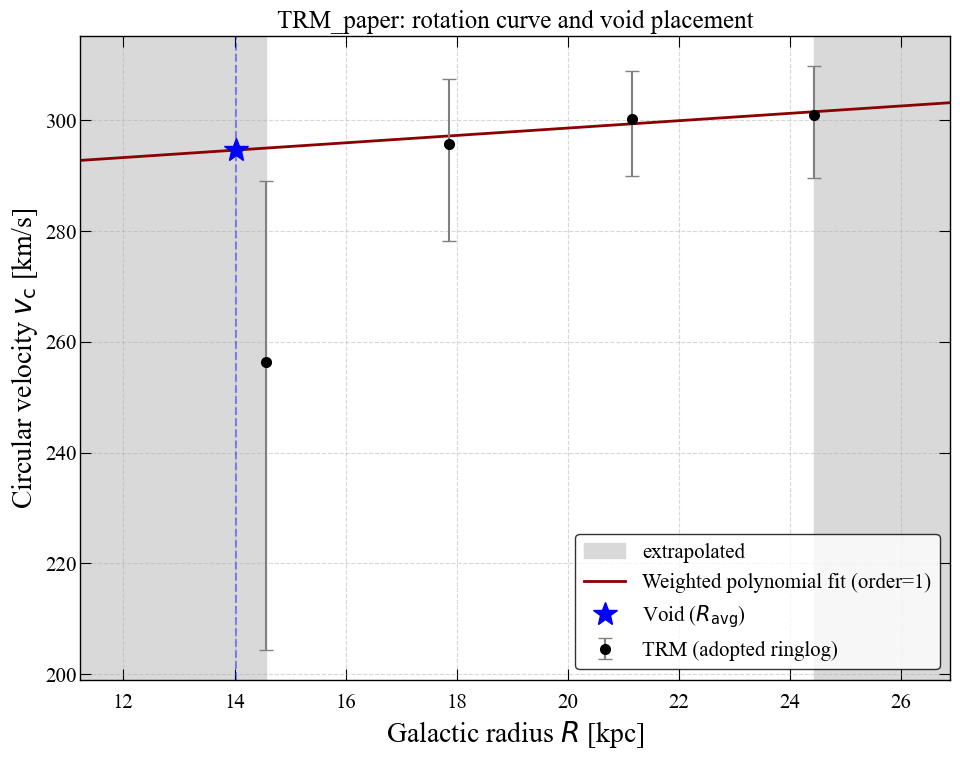

In [4]:
def fig_rotation_curve(rc, void, cfg):
    r_min, r_max = rc.radii_kpc.min(), rc.radii_kpc.max()
    r_lo_plot = min(r_min, void.r_avg_kpc) * 0.8
    r_hi_plot = max(r_max, void.r_avg_kpc) * 1.1
    R_grid = np.linspace(r_lo_plot, r_hi_plot, 300)
    v_grid = rc.curve(R_grid)

    fig, ax = plt.subplots(figsize=(10, 8))
    if r_lo_plot < r_min:
        ax.axvspan(r_lo_plot, r_min, color="0.85", zorder=0, label="extrapolated")
    if r_hi_plot > r_max:
        ax.axvspan(r_max, r_hi_plot, color="0.85", zorder=0)
    ax.plot(R_grid, v_grid, color="darkred", lw=2,
            label=f"Weighted polynomial fit (order={cfg.rotation_curve_poly_order})")
    ax.errorbar(rc.radii_kpc, rc.v_kms, yerr=[rc.v_err_lo, rc.v_err_hi], fmt="o", color="black",
                ecolor="gray", capsize=5, elinewidth=1.5, markersize=7, label="TRM (adopted ringlog)")
    ax.plot(void.r_avg_kpc, void.v_c_void_kms, "*", color="blue", markersize=18, label="Void ($R_\\mathrm{avg}$)")
    ax.axvline(void.r_avg_kpc, color="blue", linestyle="--", alpha=0.4)

    ax.set_xlabel("Galactic radius $R$ [kpc]")
    ax.set_ylabel(r"Circular velocity $v_{\mathrm{c}}$ [km/s]")
    ax.set_xlim(r_lo_plot, r_hi_plot)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="lower right", frameon=True)
    ax.set_title(f"{TRM_DIR}: rotation curve and void placement")
    fig.tight_layout()
    return fig

fig_rotation_curve(rc, void, cfg)
None

## 3. Per-ring clocks: `T_phi`, `T_kappa`, `T_kappa/2`

Reported per ring, not as a single global number -- a single impact time `t`
cannot place every ring at turnaround simultaneously (the original notebook
quoted one `T_kappa/2` at one radius as though it were global).

In [5]:
T_phi_ring, T_kappa_ring, T_kappa_half_ring = ts.t_kappa_half_per_ring(rc)
print(f"{'R [kpc]':>10}{'T_phi [Myr]':>14}{'T_kappa [Myr]':>16}{'T_kappa/2 [Myr]':>18}")
for R, tphi, tk, tkh in zip(rc.radii_kpc, T_phi_ring, T_kappa_ring, T_kappa_half_ring):
    print(f"{R:10.3f}{tphi:14.1f}{tk:16.1f}{tkh:18.1f}")

   R [kpc]   T_phi [Myr]   T_kappa [Myr]   T_kappa/2 [Myr]
    14.572         303.5           211.1             105.6
    17.860         369.2           256.0             128.0
    21.147         434.0           299.9             149.9
    24.434         497.8           342.9             171.4


## Figure 2: orbital and epicyclic clocks vs. radius

`T_phi(R)`, `T_kappa(R)`, and `T_kappa(R)/2` together with the void's
interaction-timescale upper limit and the epoch window
(`cfg.t_estimate_lo_myr` -- `cfg.t_estimate_hi_myr`) used to quote the `V0`
upper limit below, as horizontal reference lines.

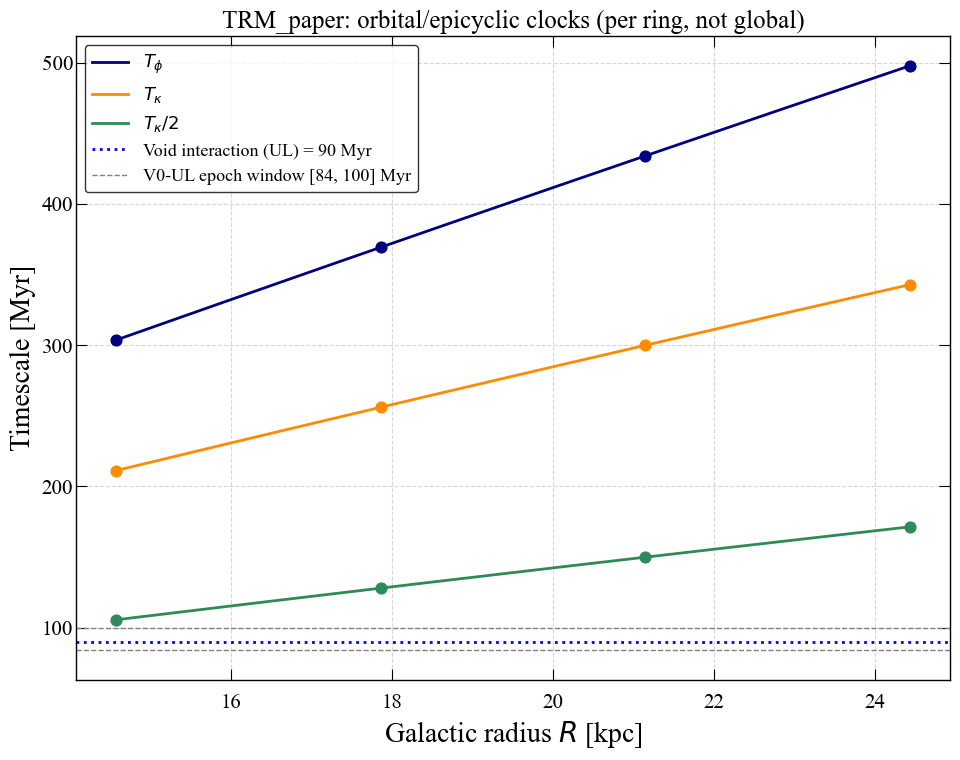

In [6]:
def fig_clocks(rc, void, cfg):
    R_grid = np.linspace(rc.radii_kpc.min(), rc.radii_kpc.max(), 200)
    Omega_g, kappa_g = ts.calculate_frequencies(R_grid, rc.curve)
    Tphi_g, Tk_g = ts.calculate_timescales(Omega_g, kappa_g)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.plot(R_grid, Tphi_g, color="navy", lw=2, label=r"$T_\phi$")
    ax.plot(R_grid, Tk_g, color="darkorange", lw=2, label=r"$T_\kappa$")
    ax.plot(R_grid, Tk_g / 2.0, color="seagreen", lw=2, label=r"$T_\kappa/2$")
    ax.scatter(rc.radii_kpc, T_phi_ring, color="navy", s=60, zorder=5)
    ax.scatter(rc.radii_kpc, T_kappa_ring, color="darkorange", s=60, zorder=5)
    ax.scatter(rc.radii_kpc, T_kappa_half_ring, color="seagreen", s=60, zorder=5)

    ax.axhline(void.t_interaction_myr, color="blue", linestyle=":", lw=2,
               label=f"Void interaction (UL) = {void.t_interaction_myr:.0f} Myr")
    ax.axhline(cfg.t_estimate_lo_myr, color="gray", linestyle="--", lw=1)
    ax.axhline(cfg.t_estimate_hi_myr, color="gray", linestyle="--", lw=1,
               label=f"V0-UL epoch window [{cfg.t_estimate_lo_myr:.0f}, {cfg.t_estimate_hi_myr:.0f}] Myr")

    ax.set_xlabel("Galactic radius $R$ [kpc]")
    ax.set_ylabel("Timescale [Myr]")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="best", frameon=True, fontsize=13)
    ax.set_title(f"{TRM_DIR}: orbital/epicyclic clocks (per ring, not global)")
    fig.tight_layout()
    return fig

fig_clocks(rc, void, cfg)
None

## 4. The epicyclic ("kick") grid search

`alpha` is fixed at `cfg.alpha` (Wallin & Struck-Marcell 1994, Sec 3.1),
never fitted -- four rings cannot constrain three free parameters, and the
original `curve_fit` run pegged its amplitude at the lower search bound
(`V0 = 10.0`, exactly), which is why its `t = 94.5 +/- 338.2 Myr` was never a
real measurement. `chi2(V0, t)` is evaluated on a deterministic 2D grid
instead -- no optimiser anywhere in this path.

In [7]:
grid = ts.epicyclic_chi2_grid(cfg, rv, rc)
print(f"chi2 minimum on the grid: {grid.chi2_min:.2f} at V0={grid.V0_at_min:.1f} km/s, t={grid.t_at_min:.1f} Myr")
print("(V0 -> 0 drives t completely unconstrained -- Sec 3.1 -- so this minimum is not a measurement.)")

ul = ts.v0_upper_limit(grid, cfg.t_estimate_lo_myr, cfg.t_estimate_hi_myr, cfg.upper_limit_cl)
print(f"\nV0 upper limit ({ul['cl']:.0%} CL, t in [{cfg.t_estimate_lo_myr:.0f}, {cfg.t_estimate_hi_myr:.0f}] Myr):")
print(f"  V0 <~ {ul['V0_upper_limit_tightest_kms']:.1f} km/s  (tightest, at t={ul['t_at_tightest_myr']:.1f} Myr)")
for t, v0 in zip(ul["t_grid_myr"][:: max(1, len(ul['t_grid_myr']) // 8)],
                  ul["V0_upper_limit_kms"][:: max(1, len(ul['t_grid_myr']) // 8)]):
    print(f"    t={t:6.1f} Myr  ->  V0 <~ {v0:5.1f} km/s")

chi2 minimum on the grid: 3.07 at V0=63.0 km/s, t=96.0 Myr
(V0 -> 0 drives t completely unconstrained -- Sec 3.1 -- so this minimum is not a measurement.)

V0 upper limit (68% CL, t in [84, 100] Myr):
  V0 <~ 107.0 km/s  (tightest, at t=84.0 Myr)
    t=  84.0 Myr  ->  V0 <~ 107.0 km/s
    t=  86.0 Myr  ->  V0 <~ 109.0 km/s
    t=  88.0 Myr  ->  V0 <~ 112.0 km/s
    t=  90.0 Myr  ->  V0 <~ 115.0 km/s
    t=  92.0 Myr  ->  V0 <~ 118.0 km/s
    t=  94.0 Myr  ->  V0 <~ 122.0 km/s
    t=  96.0 Myr  ->  V0 <~ 126.0 km/s
    t=  98.0 Myr  ->  V0 <~ 129.0 km/s
    t= 100.0 Myr  ->  V0 <~ 134.0 km/s


## Figure 3: `chi2(V0, t)` contours

Filled at `Delta chi2 = 1, 4, 9`, with the `V0` upper limit's grid point
marked. The expected shape -- confirmed here, not assumed -- is a banana
opening toward `V0 -> 0`, where `t` is unconstrained: showing that
explicitly is the legitimate result; a point estimate with an undefined
error bar (the original `curve_fit` run) is not.

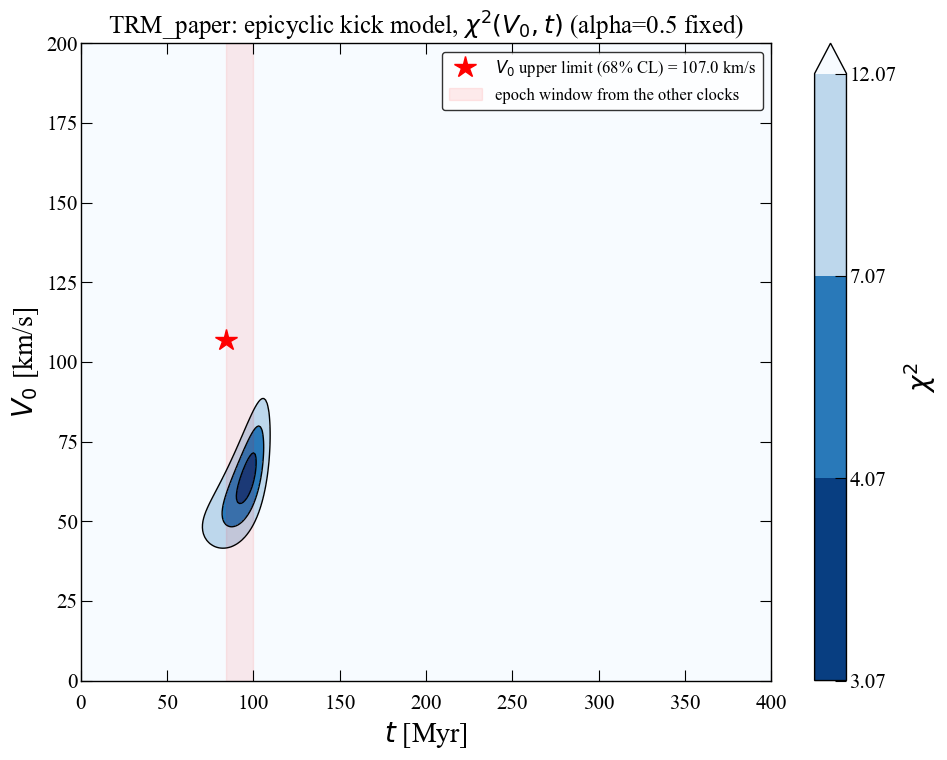

In [8]:
def fig_chi2_contours(grid, ul):
    fig, ax = plt.subplots(figsize=(10, 8))
    levels = [grid.chi2_min + d for d in (1, 4, 9)]
    cs = ax.contourf(grid.t_grid_myr, grid.V0_grid_kms, grid.chi2, levels=[grid.chi2_min] + levels,
                      cmap="Blues_r", extend="max")
    ax.contour(grid.t_grid_myr, grid.V0_grid_kms, grid.chi2, levels=levels, colors="black", linewidths=1)
    fig.colorbar(cs, ax=ax, label=r"$\chi^2$")

    ax.plot(ul["t_at_tightest_myr"], ul["V0_upper_limit_tightest_kms"], "*", color="red", markersize=16,
            label=f"$V_0$ upper limit ({ul['cl']:.0%} CL) = {ul['V0_upper_limit_tightest_kms']:.1f} km/s")
    ax.axvspan(cfg.t_estimate_lo_myr, cfg.t_estimate_hi_myr, color="red", alpha=0.08,
               label="epoch window from the other clocks")

    ax.set_xlabel("$t$ [Myr]")
    ax.set_ylabel("$V_0$ [km/s]")
    ax.legend(loc="upper right", frameon=True, fontsize=12)
    ax.set_title(f"{TRM_DIR}: epicyclic kick model, $\\chi^2(V_0, t)$ (alpha={cfg.alpha} fixed)")
    fig.tight_layout()
    return fig

fig_chi2_contours(grid, ul)
None

## Figure 4: observed vs. modelled `V_R`, per ring

At the grid's (degenerate) `chi2` minimum and at the `V0` upper limit -- to
show visually, not just via `chi2`, that a single-sign-changing kick model
cannot reproduce the ring-to-ring sign pattern in the corrected data.

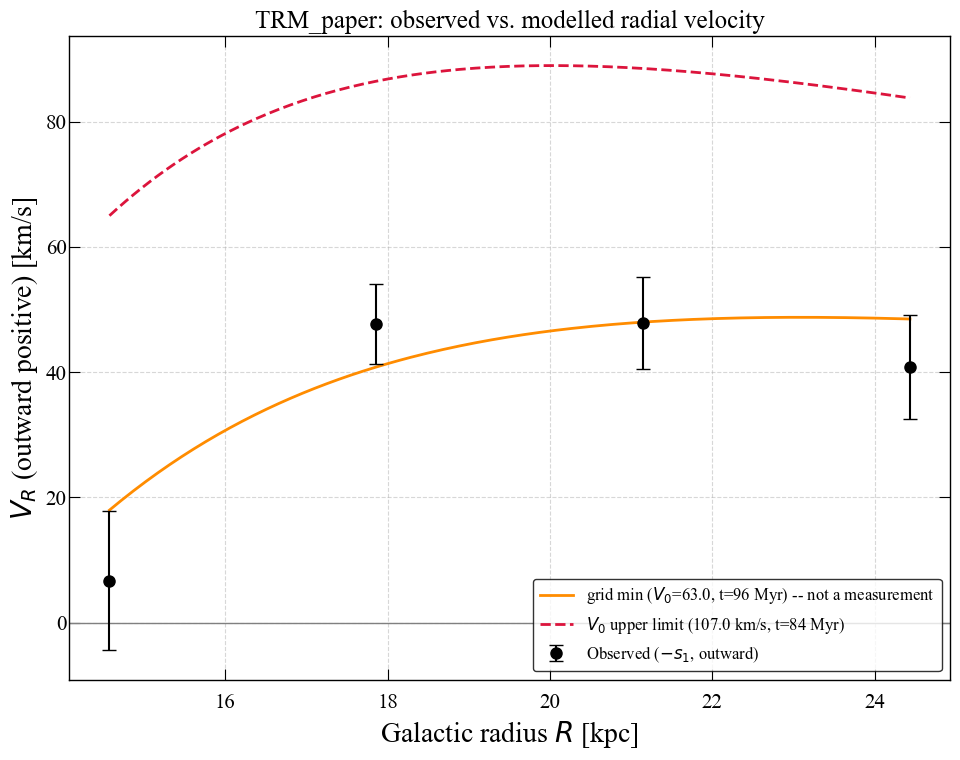

In [9]:
def fig_obs_vs_model(rv, rc, grid, ul, cfg):
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.errorbar(rv.radii_kpc, rv.v_R_outward_kms, yerr=rv.sigma_kms, fmt="o", color="black",
                capsize=5, elinewidth=1.5, markersize=8, label="Observed ($-s_1$, outward)", zorder=5)

    R_grid = np.linspace(rc.radii_kpc.min(), rc.radii_kpc.max(), 200)
    model_min = ts.kick_model_v_R(R_grid, grid.t_at_min, grid.V0_at_min, cfg.alpha, rc.curve, cfg.r_ref_kpc)
    model_ul = ts.kick_model_v_R(R_grid, ul["t_at_tightest_myr"], ul["V0_upper_limit_tightest_kms"],
                                  cfg.alpha, rc.curve, cfg.r_ref_kpc)
    ax.plot(R_grid, model_min, color="darkorange", lw=2,
            label=f"grid min ($V_0$={grid.V0_at_min:.1f}, t={grid.t_at_min:.0f} Myr) -- not a measurement")
    ax.plot(R_grid, model_ul, color="crimson", lw=2, linestyle="--",
            label=f"$V_0$ upper limit ({ul['V0_upper_limit_tightest_kms']:.1f} km/s, t={ul['t_at_tightest_myr']:.0f} Myr)")

    ax.axhline(0, color="gray", lw=1)
    ax.set_xlabel("Galactic radius $R$ [kpc]")
    ax.set_ylabel(r"$V_R$ (outward positive) [km/s]")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="best", frameon=True, fontsize=12)
    ax.set_title(f"{TRM_DIR}: observed vs. modelled radial velocity")
    fig.tight_layout()
    return fig

fig_obs_vs_model(rv, rc, grid, ul, cfg)
None

## Section 4 (spec): bridge timescale -- not computed

A real measurement of the bridge's sky-plane extent and line-of-sight
velocity difference, and its measured position angle on the sky, are
required for this section and are not present anywhere in this repo. The
machinery (`timescales.bridge_timescale_myr`,
`timescales.bridge_timescale_sensitivity`,
`timescales.validate_bridge_orientation`) is implemented and exercised in
`timescales.py`'s self-test against the spec's own worked example (a naive,
theta=45-deg-assumed `t=91.7 Myr` corrects to `t=78.8 Myr` once
`theta=i=49.345 deg` is used instead) -- set `cfg.bridge_dR_over_dV_kpc_per_kms`
and `cfg.bridge_pa_deg` once those measurements exist, and this cell will
report the corrected timescale, its sensitivity to `theta`, and the
orientation validation against `pa0 + 90`.

In [10]:
if cfg.bridge_dR_over_dV_kpc_per_kms is not None:
    theta_deg = rc.inc_deg
    t_bridge = ts.bridge_timescale_myr(cfg.bridge_dR_over_dV_kpc_per_kms, theta_deg)
    sens = ts.bridge_timescale_sensitivity(theta_deg, cfg.bridge_theta_sensitivity_step_deg)
    print(f"t_bridge = {t_bridge:.1f} Myr (theta = i = {theta_deg:.3f} deg)")
    print(f"sensitivity: delta_t/t = {sens:.1%} per {cfg.bridge_theta_sensitivity_step_deg:.0f} deg near theta={theta_deg:.1f} deg")
    ts.validate_bridge_orientation(cfg.bridge_pa_deg, rc.pa_deg)
else:
    print("Skipped: cfg.bridge_dR_over_dV_kpc_per_kms is None (see markdown cell above).")

Skipped: cfg.bridge_dR_over_dV_kpc_per_kms is None (see markdown cell above).


## Write `results/timescales.json`

In [11]:
results = ts.run(cfg)
ts.write_results(cfg, results)
None

[timescales] Section 4 (bridge) SKIPPED: bridge_dR_over_dV_kpc_per_kms not supplied in Config.
[timescales] Wrote /Users/24398082/projects/SM_harmonic_fit/TRM_paper/results/timescales.json


/Users/24398082/projects/SM_harmonic_fit/timescales.py:183: UserWarning: void R_avg: evaluating the rotation-curve fit 0.553 kpc below the innermost ring (14.572 kpc) -- dv/dR (and kappa) is extrapolated, not measured.
  warnings.warn(


## Closing summary

- **Inputs.** Every ring parameter above traces to `TRM_paper`'s own
  ringlog; the radial-velocity array traces to its own
  `results/ring_results.ecsv`, sign-flipped once, explicitly, to match this
  project's outward-positive convention.
- **Void geometry.** Recomputed with the project's own deprojection
  convention (Section 2 above) instead of a second, differently-handed one;
  the interaction timescale is reported as an **upper limit** (Wallin &
  Struck-Marcell 1994, Sec 3.3.3 -- the hole keeps expanding after
  formation).
- **The epicyclic fit is not a measurement of `t`.** Four rings and an
  amplitude that multiplies the entire model cannot constrain a three (or
  even two) parameter fit when the data are consistent with zero amplitude
  -- the grid search shows this explicitly (Figure 3) rather than hiding it
  behind an optimiser's undefined error bar. The salvageable result is the
  **upper limit on `V0`** at the epoch indicated by the void and (once
  supplied) bridge clocks.
- **`T_kappa/2` is reported per ring** (Section 3), not as a single global
  number -- no single impact time places every ring at turnaround at once.